In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import openml

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import ParameterGrid

import mlflow

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Загрузка датасета "Credit Card Dataset for Clustering"
file_path = "../data/credit_cards_dataset.csv"

try:
    df = pd.read_csv(file_path)
    print(f"Датасет успешно загружен! Размер: {df.shape}")
except FileNotFoundError:
    print("ОШИБКА: Файл не найден.")

Датасет успешно загружен! Размер: (8950, 18)


In [3]:
df.drop(['CUST_ID'], axis=1, inplace=True)
# заполняем пропуски
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)

In [4]:
log_cols = [
    'BALANCE',
    'PURCHASES',
    'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE',
    'PAYMENTS',
    'MINIMUM_PAYMENTS',
    'CASH_ADVANCE_TRX',
    'CREDIT_LIMIT',
    'PURCHASES_TRX'
]

for col in log_cols:
    df[col] = np.log(1 + df[col])

In [10]:
selected_features = [
    'PURCHASES',
    'CASH_ADVANCE',
    'INSTALLMENTS_PURCHASES',

    'PURCHASES_FREQUENCY',
    'CASH_ADVANCE_FREQUENCY',

    'PRC_FULL_PAYMENT',

    'CREDIT_LIMIT',
    'TENURE'
]

df_selected = df[selected_features]
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_selected)
df_scaled = pd.DataFrame(data_scaled, columns=selected_features)

Baseline Model (K-Means Default)

In [59]:
print("Baseline K-Means (k=4 default)")

kmeans_base = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_base = kmeans_base.fit_predict(df_scaled)

sil_base = silhouette_score(df_scaled, clusters_base)
db_base = davies_bouldin_score(df_scaled, clusters_base)
ch_base = calinski_harabasz_score(df_scaled, clusters_base)

baseline_results = {
    'model': 'Baseline_KMeans',
    'silhouette': sil_base,
    'davies_bouldin': db_base,
    'calinski_harabasz': ch_base,
    'params': {'n_clusters': 4}
}

baseline_results

Baseline K-Means (k=4 default)


{'model': 'Baseline_KMeans',
 'silhouette': 0.293751155045553,
 'davies_bouldin': 1.3647184056015742,
 'calinski_harabasz': 3031.9682281831474,
 'params': {'n_clusters': 4}}

K-Means: Подбор гиперпараметров

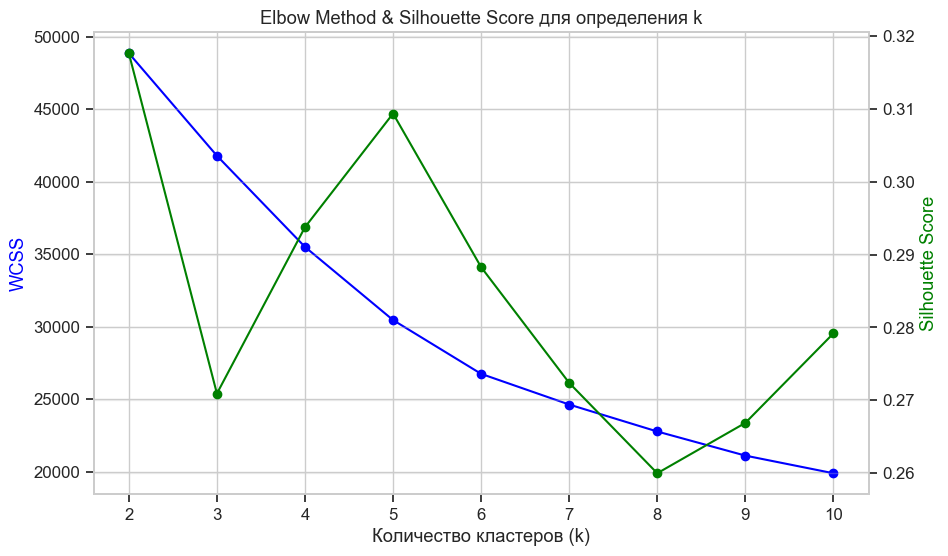

In [60]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []
range_k = range(2, 11)

for k in range_k:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('Количество кластеров (k)')
ax1.set_ylabel('WCSS (Inertia)', color='blue')
ax1.plot(range_k, wcss, marker='o', color='blue', label='WCSS')
ax1.set_ylabel('WCSS', color='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='green')
ax2.plot(range_k, silhouette_scores, marker='o', color='green', label='Silhouette')

plt.title('Elbow Method & Silhouette Score для определения k')
plt.grid(True, alpha=0.3)
plt.savefig('../artifacts/figures/elbow_silhouette_kmeans.png')
plt.show()

In [63]:
print("Hyperparameter Tuning for K-Means")

param_grid = {
    'n_clusters': [3, 4, 5, 6, 7],
    'init': ['k-means++', 'random'],
    'n_init': [5, 7, 10, 12]
}

best_score = -1
best_params = None
best_model = None
results_log = []

for params in ParameterGrid(param_grid):
    km = KMeans(**params, random_state=42)
    labels = km.fit_predict(data_scaled)
    
    sil = silhouette_score(data_scaled, labels)
    db = davies_bouldin_score(data_scaled, labels)
    ch = calinski_harabasz_score(data_scaled, labels)
    
    current_result = {
        'params': params,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    }
    results_log.append(current_result)
    
    if sil > best_score:
        best_score = sil
        best_params = params
        best_model = km

print(f"Best K-Means Params: {best_params}")
print(f"Best Silhouette Score: {best_score:.4f}")

best_clusters = best_model.predict(data_scaled)

tuned_kmeans_results = {
    'model': 'KMeans_Tuned',
    'silhouette': best_score,
    'davies_bouldin': davies_bouldin_score(data_scaled, best_clusters),
    'calinski_harabasz': calinski_harabasz_score(data_scaled, best_clusters),
    'params': best_params
}

tuned_kmeans_results

Hyperparameter Tuning for K-Means
Best K-Means Params: {'init': 'k-means++', 'n_clusters': 5, 'n_init': 10}
Best Silhouette Score: 0.3093


{'model': 'KMeans_Tuned',
 'silhouette': 0.3093353780705341,
 'davies_bouldin': 1.2136103150059232,
 'calinski_harabasz': 3020.541924611946,
 'params': {'init': 'k-means++', 'n_clusters': 5, 'n_init': 10}}

DBSCAN

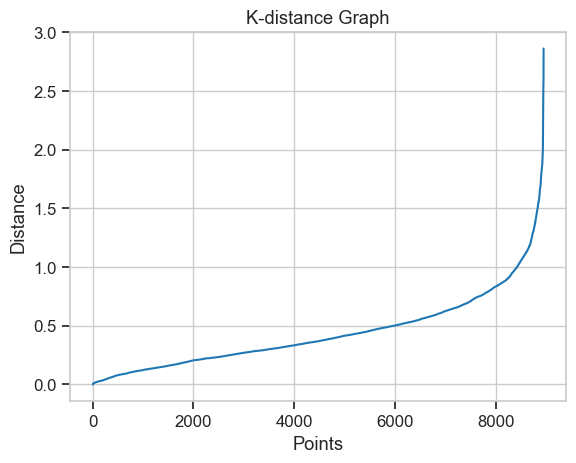

array([0.        , 0.        , 0.        , ..., 2.57797398, 2.59550698,
       2.86309137], shape=(8950,))

In [64]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Метод k-distance graph для подбора eps
def find_optimal_eps(data, k=5):
    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(data)
    distances, indices = neighbors_fit.kneighbors(data)
    distances = np.sort(distances[:, k-1])

    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel('Distance')
    plt.title('K-distance Graph')
    plt.savefig('../artifacts/figures/k_distance_graph_dbscan.png')
    plt.show()

    return distances

find_optimal_eps(df_scaled, k=5)

In [67]:
print("Hyperparameter Tuning for DBSCAN")

best_db_score = -1
best_db_params = None
best_db_model = None

eps_values = [0.8, 0.9, 1.0, 1.1]
min_samples_values = [5, 10, 15]

for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(data_scaled)

        if -1 in labels:
            mask = labels != -1
            data = data_scaled[mask]
            labels = labels[mask]
        sil = silhouette_score(data, labels)
        if sil > best_db_score:
                best_db_score = sil
                best_db_params = {'eps': eps, 'min_samples': min_s}
                best_db_model = db

if best_db_model is None:
    best_db_model = DBSCAN(eps=0.9, min_samples=10)
    best_db_params = {'eps': 0.9, 'min_samples': 10}

labels = best_db_model.fit_predict(data_scaled)

if -1 in labels:
    mask = labels != -1
    data = data_scaled[mask]
    labels = labels[mask]

sil_score = silhouette_score(data, labels)
db_score = davies_bouldin_score(data, labels)
ch_score = calinski_harabasz_score(data, labels)

dbscan_results = {
    'model': 'DBSCAN',
    'silhouette': sil_score,
    'davies_bouldin': db_score,
    'calinski_harabasz': ch_score,
    'params': best_db_params
}

dbscan_results

Hyperparameter Tuning for DBSCAN


{'model': 'DBSCAN',
 'silhouette': 0.26872254388322736,
 'davies_bouldin': 0.7984672914310943,
 'calinski_harabasz': 34.99208947896335,
 'params': {'eps': 1.0, 'min_samples': 15}}

In [68]:
print("Agglomerative Clustering")

agglo = AgglomerativeClustering(n_clusters=best_params['n_clusters'], linkage='ward')
agglo_clusters = agglo.fit_predict(data_scaled)

sil_agglo = silhouette_score(data_scaled, agglo_clusters)
db_agglo = davies_bouldin_score(data_scaled, agglo_clusters)
ch_agglo = calinski_harabasz_score(data_scaled, agglo_clusters)

agglo_results = {
    'model': 'Agglomerative_Ward',
    'silhouette': sil_agglo,
    'davies_bouldin': db_agglo,
    'calinski_harabasz': ch_agglo,
    'params': {'n_clusters': best_params['n_clusters'], 'linkage': 'ward'}
}

agglo_results

Agglomerative Clustering


{'model': 'Agglomerative_Ward',
 'silhouette': 0.2762958269072885,
 'davies_bouldin': 1.3045072526715829,
 'calinski_harabasz': 2648.790765145038,
 'params': {'n_clusters': 5, 'linkage': 'ward'}}

Эксперименты и трекинг

In [70]:
print("Logging Experiments to MLflow")

mlflow.set_experiment("Credit_Card_Clustering_Experiments")

models_to_compare = [
    baseline_results,
    tuned_kmeans_results,
    dbscan_results,
    agglo_results
]

with mlflow.start_run(run_name="Clustering_Comparison"):
    for res in models_to_compare:
        with mlflow.start_run(run_name=res['model'], nested=True):

            mlflow.log_params(res['params'])
            
            mlflow.log_metric("silhouette_score", res['silhouette'])
            mlflow.log_metric("davies_bouldin_score", res['davies_bouldin'])
            mlflow.log_metric("calinski_harabasz_score", res['calinski_harabasz'])
            
            print(f"Logged: {res['model']} | Sil: {res['silhouette']:.4f}")


    summary_df = pd.DataFrame(models_to_compare)
    summary_df.to_csv("../artifacts/experiment_summary.csv", index=False)
    mlflow.log_artifact("../artifacts/experiment_summary.csv")

print("Experiments logged to MLflow")

Logging Experiments to MLflow
Logged: Baseline_KMeans | Sil: 0.2938
Logged: KMeans_Tuned | Sil: 0.3093
Logged: DBSCAN | Sil: 0.2687
Logged: Agglomerative_Ward | Sil: 0.2763
Experiments logged to MLflow


Выбор финальной модели

In [73]:
summary_df.sort_values(['silhouette'], ascending=False)

,model,silhouette,davies_bouldin,calinski_harabasz,params
1,KMeans_Tuned,0.309335,1.213610,3020.541925,"{'init': 'k-means++', 'n_clusters': 5, 'n_init..."
0,Baseline_KMeans,0.293751,1.364718,3031.968228,{'n_clusters': 4}
3,Agglomerative_Ward,0.276296,1.304507,2648.790765,"{'n_clusters': 5, 'linkage': 'ward'}"
2,DBSCAN,0.268723,0.798467,34.992089,"{'eps': 1.0, 'min_samples': 15}"


`Silhouette`: чем ближе к 1, тем лучше разделение кластеров. Отрицательные значения означают, что точки отнесены не к тому кластеру.

`Davies-Bouldin`: чем ближе к 0, тем лучше (меньше перекрытия кластеров).

`Calinski-Harabasz`: чем выше, тем плотнее кластеры и дальше друг от друга.

K-Means Tuned показал лучшие результаты по метрикам 

In [74]:
print("Model Selection")


valid_models = [m for m in models_to_compare if m['silhouette'] > 0]
if valid_models:
    best_overall = max(valid_models, key=lambda x: x['silhouette'])
else:
    best_overall = tuned_kmeans_results

print(f"Best Model Selected: {best_overall['model']}")

Model Selection
Best Model Selected: KMeans_Tuned


In [ ]:
# --- 7. Model Packaging and Artifacts ---
print("\n--- Packaging Model and Artifacts ---")

import joblib
import os
import yaml

# Save the best model
if best_overall['model'] == 'KMeans_Tuned':
    model_obj = best_model
elif best_overall['model'] == 'Agglomerative_Ward':
    model_obj = agglo
else:
    model_obj = best_model # Default to best KMeans for this example

joblib.dump(model_obj, "../artifacts/best_model.pkl")
joblib.dump(scaler, "../artifacts/scaler.pkl")

# Save Feature List
feature_list = selected_features
with open("../artifacts/features.yaml", 'w') as f:
    yaml.dump({"features": feature_list}, f)

# Save Config
config = {
    "model_type": best_overall['model'],
    "parameters": best_overall['params'],
    "metrics": {
        "silhouette": best_overall['silhouette'],
        "davies_bouldin": best_overall['davies_bouldin'],
        "calinski_harabasz": best_overall['calinski_harabasz']
    },
    "features": feature_list
}

with open("../artifacts/config.yaml", 'w') as f:
    yaml.dump(config, f)

print("Model and artifacts saved to 'artifacts/' folder.")
print("Files saved:")
print("- best_model.pkl")
print("- scaler.pkl")
print("- features.yaml")
print("- config.yaml")


--- Packaging Model and Artifacts ---
Model and artifacts saved to 'artifacts/' folder.
Files saved:
- best_clustering_model.pkl
- scaler.pkl
- features.yaml
- config.yaml


In [56]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import time

# 1. Сбор меток всех моделей
# Убедитесь, что эти переменные существуют после ваших предыдущих ячеек с обучением

# Для DBSCAN и Agglomerative нужно получить метки, если они еще не сохранены в отдельные переменные
# В предыдущем коде мы сохраняли результаты в словари, давайте извлечем метки:

# Baseline K-Means (k=4)
labels_kmeans_base = clusters_base 

# NN Baseline (Autoencoder + KMeans k=4)
labels_nn = clusters_nn

# Tuned K-Means (лучшая модель из grid search)
labels_kmeans_tuned = best_clusters

# DBSCAN (лучшая модель из поиска)
# Важно: DBSCAN может иметь шум (-1). Мы берем метки из лучшей модели, которую нашли
db_model = dbscan_results['model'] # или best_db_model, зависит от именования в вашей ячейке
labels_dbscan = best_db_model.fit_predict(data_scaled)

# Agglomerative
agglo_model = agglo_results['model'] # или просто agglo, если вы сохраняли объект
labels_agglo = agglo.fit_predict(data_scaled)

# Создаем DataFrame с метками
df_labels = pd.DataFrame({
    'KMeans_Base': labels_kmeans_base,
    'NN_Baseline': labels_nn,
    'KMeans_Tuned': labels_kmeans_tuned,
    'DBSCAN': labels_dbscan,
    'Agglomerative': labels_agglo
})

print("Метки всех моделей собраны.")
print(df_labels.head())

Метки всех моделей собраны.
   KMeans_Base  NN_Baseline  KMeans_Tuned  DBSCAN  Agglomerative
0            3            1             3       0              0
1            1            0             1       0              2
2            3            1             3       0              0
3            1            1             1       0              2
4            3            1             3       0              0


Запуск t-SNE... Это может занять некоторое время.
t-SNE выполнено за 56.80 секунд
Размерность после t-SNE: (8950, 2)


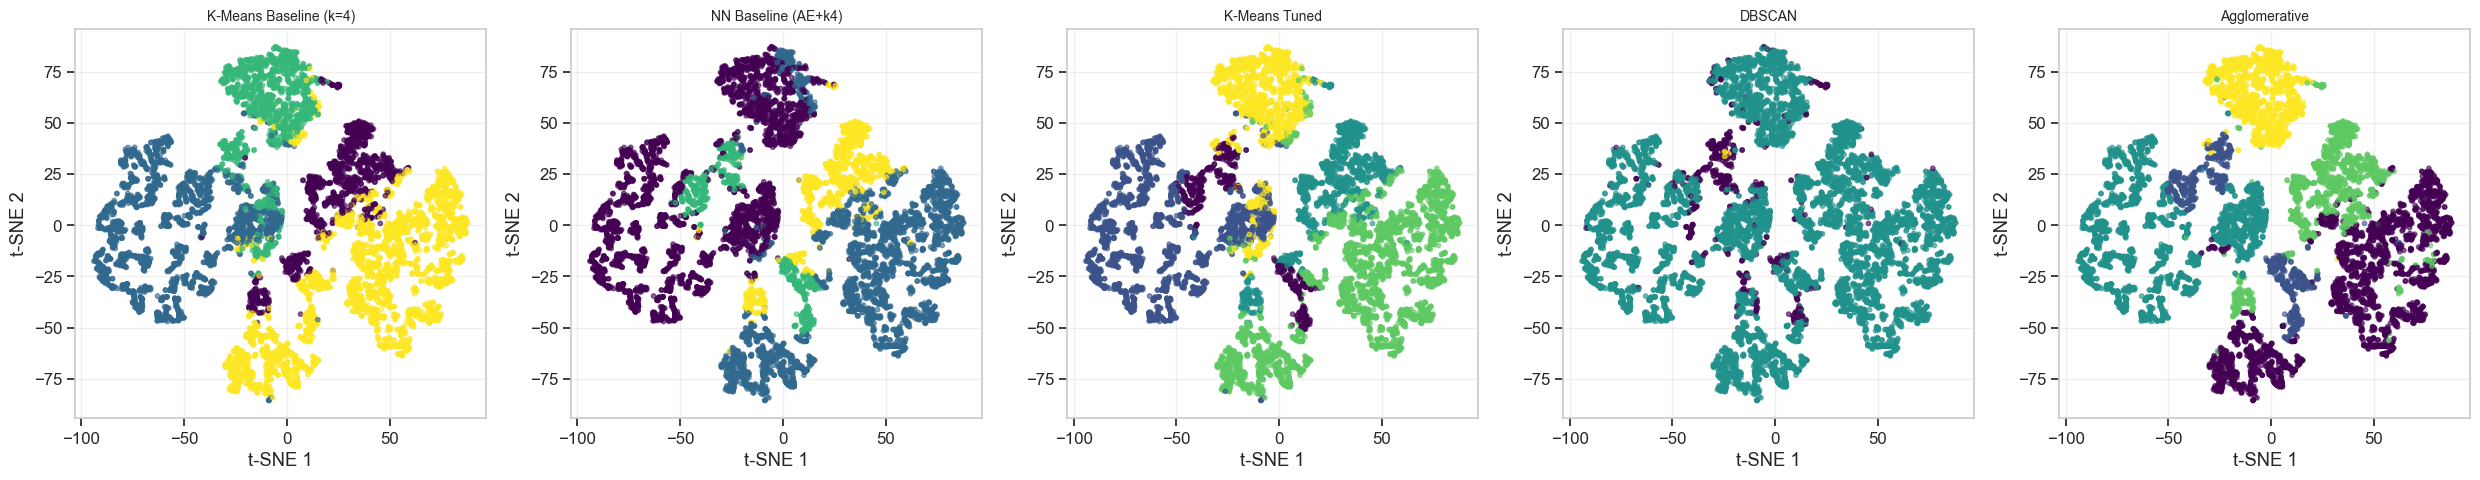

In [58]:
# 2. Применение t-SNE
print("Запуск t-SNE... Это может занять некоторое время.")
start_time = time.time()

# Используем data_scaled (numpy array), который мы получали ранее
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto')
X_tsne = tsne.fit_transform(data_scaled)

print(f"t-SNE выполнено за {time.time() - start_time:.2f} секунд")
print(f"Размерность после t-SNE: {X_tsne.shape}")

# 3. Визуализация результатов кластеризации в пространстве t-SNE
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

models_names = ['KMeans_Base', 'NN_Baseline', 'KMeans_Tuned', 'DBSCAN', 'Agglomerative']
titles = [
    'K-Means Baseline (k=4)', 
    'NN Baseline (AE+k4)', 
    'K-Means Tuned', 
    'DBSCAN', 
    'Agglomerative'
]

for i, (col_name, title) in enumerate(zip(models_names, titles)):
    labels = df_labels[col_name].values
    
    scatter = axes[i].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                              c=labels, 
                              cmap='viridis', 
                              alpha=0.6, 
                              s=10)
    axes[i].set_title(title, fontsize=10)
    axes[i].set_xlabel('t-SNE 1')
    axes[i].set_ylabel('t-SNE 2')
    axes[i].grid(True, alpha=0.3)
    
    # Убираем_ticks для чистоты, если нужно
    # axes[i].set_xticks([])
    # axes[i].set_yticks([])

plt.tight_layout()
plt.savefig('clustering_tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()